# Experiment 7: Comparision of Different Regression Algorithms for Predictive Modeling

# Cell 1 — Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cell 2 — Load dataset

In [2]:
df = pd.read_csv("insurance.csv")

print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


# Cell 3 — Check dataset

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1338, 7)

Column Names:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


# Cell 4 — Separate features and target

In [4]:
X = df.drop("charges", axis=1)
y = df["charges"]

print("Input Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input Features:
   age     sex     bmi  children smoker     region
0   19  female  27.900         0    yes  southwest
1   18    male  33.770         1     no  southeast
2   28    male  33.000         3     no  southeast
3   33    male  22.705         0     no  northwest
4   32    male  28.880         0     no  northwest

Target:
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


# Cell 5 — Identify categorical and numerical columns

In [5]:
categorical_columns = ["sex", "smoker", "region"]

numerical_columns = [
    "age",
    "bmi",
    "children"
]

print("Categorical columns:", categorical_columns)
print("Numerical columns:", numerical_columns)

Categorical columns: ['sex', 'smoker', 'region']
Numerical columns: ['age', 'bmi', 'children']


# Cell 6 — Preprocess categorical data

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

# Cell 7 — Train-test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1070, 6)
Testing data: (268, 6)


# Cell 8 — Preprocess the data

In [9]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed.")

Preprocessing completed.


# 1. Linear Regression
# Cell 9 — Train Linear Regression

In [10]:
lr = LinearRegression()

lr.fit(X_train_processed, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


# Cell 10 — Prediction

In [11]:
y_pred_lr = lr.predict(X_test_processed)

print("Predicted values:")
print(y_pred_lr[:10])

Predicted values:
[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656 10864.11316424   170.28084136 16903.45028662
  1092.43093614 11218.34318352]


# Cell 11 — Evaluation

In [12]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression
MAE: 4181.19447375365
MSE: 33596915.85136147
RMSE: 5796.2846592762735
R2 Score: 0.7835929767120723


# 2. Decision Tree Regression
# Cell 12 — Train Decision Tree

In [13]:
dt = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

dt.fit(X_train_processed, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


# Cell 13 — Prediction

In [14]:
y_pred_dt = dt.predict(X_test_processed)

print("Predicted values:")
print(y_pred_dt[:10])

Predicted values:
[10550.64043734  5243.04129723 26871.09152294 10550.64043734
 34232.77860769  5243.04129723  1847.03152738 15110.422598
  5243.04129723 10550.64043734]


# Cell 14 — Evaluation

In [15]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regression")
print("MAE:", mae_dt)
print("MSE:", mse_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree Regression
MAE: 2911.1600498786065
MSE: 25857792.058551632
RMSE: 5085.055757663984
R2 Score: 0.8334428126395235


# 3. Random Forest Regression
# Cell 15 — Train Random Forest 

In [16]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_processed, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


# Cell 16 — Prediction

In [17]:
y_pred_rf = rf.predict(X_test_processed)

print("Predicted values:")
print(y_pred_rf[:10])

Predicted values:
[10028.9840169  5358.250527  28106.407921  12687.3942676 34681.5653793
  8549.9644695  2085.7117515 14385.9434137  5867.6741929 10987.3024623]


# Cell 17 — Evaluation

In [18]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Regression
MAE: 2545.869462487625
MSE: 21024333.61167968
RMSE: 4585.229940982205
R2 Score: 0.8645764547661136


# 4. KNN Regression
# Cell 18 — Train KNN

In [19]:
knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_processed, y_train)

print("KNN model trained successfully.")

KNN model trained successfully.


# Cell 19 — Prediction

In [20]:
y_pred_knn = knn.predict(X_test_processed)

print("Predicted values:")
print(y_pred_knn[:10])

Predicted values:
[ 8969.27286   5637.40824  25167.10517  13092.752768 21178.82044
  6490.195774  3206.98961  11676.02791   4157.39993  10037.89902 ]


# Cell 20 — Evaluation

In [21]:
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("KNN Regression")
print("MAE:", mae_knn)
print("MSE:", mse_knn)
print("RMSE:", rmse_knn)
print("R2 Score:", r2_knn)

KNN Regression
MAE: 3631.59117925
MSE: 35984256.904628225
RMSE: 5998.687931925466
R2 Score: 0.7682154529775659


# 5. Compare all algorithms
# Cell 21 — Comparison table

In [22]:
results = pd.DataFrame({
    "Algorithm": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf,
        mae_knn
    ],
    "MSE": [
        mse_lr,
        mse_dt,
        mse_rf,
        mse_knn
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_knn
    ],
    "R2 Score": [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_knn
    ]
})

print(results)

           Algorithm          MAE           MSE         RMSE  R2 Score
0  Linear Regression  4181.194474  3.359692e+07  5796.284659  0.783593
1      Decision Tree  2911.160050  2.585779e+07  5085.055758  0.833443
2      Random Forest  2545.869462  2.102433e+07  4585.229941  0.864576
3                KNN  3631.591179  3.598426e+07  5998.687932  0.768215


# 6. R² Score comparison

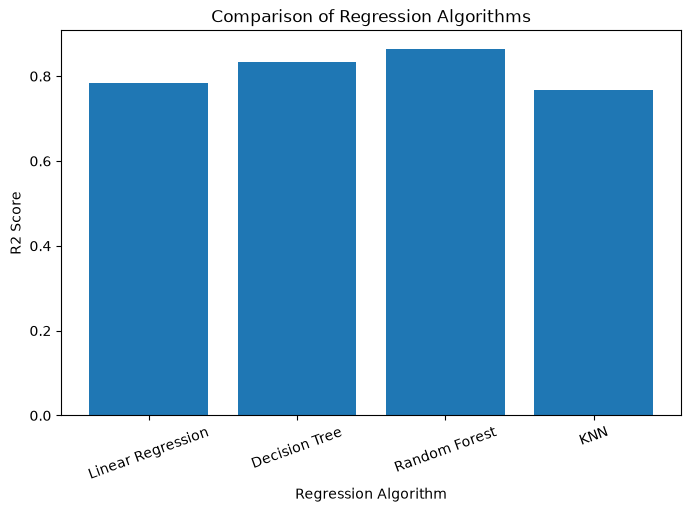

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Algorithm"],
    results["R2 Score"]
)

plt.xlabel("Regression Algorithm")
plt.ylabel("R2 Score")
plt.title("Comparison of Regression Algorithms")

plt.xticks(rotation=20)
plt.show()

# 7. RMSE comparison

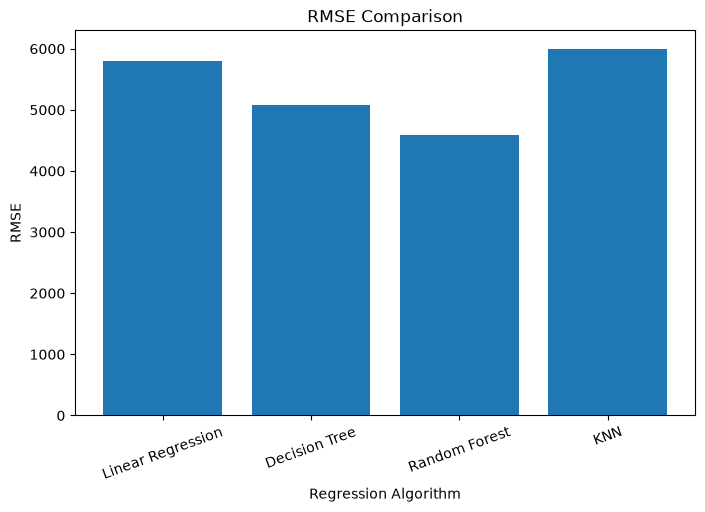

In [24]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Algorithm"],
    results["RMSE"]
)

plt.xlabel("Regression Algorithm")
plt.ylabel("RMSE")
plt.title("RMSE Comparison")

plt.xticks(rotation=20)
plt.show()